# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Sneha Kanjwani

**Roll Number:** 023-24-0273

**GitHub Repository:** https://github.com/snehakanjwani30/lab-2-telco-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv") 
print(df.head()) # update path/filename if different

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The company is losing customers to other competitors and wants to know the reason behind the customer's leaving. 
Our goad is to find the customers that are likely to leave the company so we could take an action. 
The target variable here is CHURN because it tells whether a customer has left or not.

**Answer 2:**
Useful:
Tenure : Customers who have been within the company for a short time could more offen leave early.
Contract: Customers with difference in contracts could also be a reason.
Monthly Charges: Customers with heigher monthly charges could also more likely to leave.
Internet Services: Customers having problems in internet services are also considered.
TechSupport: Customers without a proper technical support might also be the reason behind leaving.

Useless:
CustomerID: It could not be a reason of any customer for leaving.
gender: Gender could not be a strong reason anything to leave a telecom company.
    
**Answer 3:**
Does the type of contract a customer is having could be a reason for them to leave?
Does higher monthly charges could make a customer more likely to leave?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [ ]:
# Task 4 — dataset shape, column names, data types
# 7043 customers and 21 features
# Numerical features: SeniorCitizen, tenure, MonthlyCharges.
# Categorical features: customerID, gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, 
# OnlineSecurity, OnlineBackup, DeviceProtection,TechSupport, StreamingTV, StreamingMovies, Contract, 
# PaperlessBilling, PaymentMethod, TotalCharges, Churn.

In [ ]:
# Task 5 — identify identifier columns / wrong data types
# Identifier: customerID: It is just unique ID for customers, it has nothing to do with churn.
# Wrong datatype: TotalCharges: It should be numerical but it stored as an object that should be changed.

In [ ]:
# Task 6 — unique values in 3 categorical columns
# gender: Male/Female
# InternetServices: DSL/ Fiber Optic/ No
# Contract: Month-to-month/ One year/ Two years 

**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_
The dataset contains 7,043 customers and 21 columns. It has both numerical and categorical features. 
customerID is an identifier and is not useful as a predictive feature.
I also noticed that TotalCharges is stored as an object even though it represents numerical values, 
so its data type will need to be corrected. The categorical columns I checked had consistent values.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [6]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
print(pd.DataFrame({'missing_count': missing_count, 'missing_%': missing_pct}))

blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()
blank_pct = blank_total_charges / len(df) * 100
print(f"Blank TotalCharges: {blank_total_charges} ({blank_pct:.2f}%)")

                  missing_count  missing_%
customerID                    0        0.0
gender                        0        0.0
SeniorCitizen                 0        0.0
Partner                       0        0.0
Dependents                    0        0.0
tenure                        0        0.0
PhoneService                  0        0.0
MultipleLines                 0        0.0
InternetService               0        0.0
OnlineSecurity                0        0.0
OnlineBackup                  0        0.0
DeviceProtection              0        0.0
TechSupport                   0        0.0
StreamingTV                   0        0.0
StreamingMovies               0        0.0
Contract                      0        0.0
PaperlessBilling              0        0.0
PaymentMethod                 0        0.0
MonthlyCharges                0        0.0
TotalCharges                  0        0.0
Churn                         0        0.0
Blank TotalCharges: 11 (0.16%)


In [6]:
# Task 8 — duplicate rows vs duplicate IDs
print('Duplicate rows: ',df.duplicated().sum())
print('Duplicate customer IDs: ',df['customerID'].duplicated().sum())

Duplicate rows:  0
Duplicate customer IDs:  0


In [8]:
# Task 9 — investigate a suspicious / invalid value
print(df["TotalCharges"].dtype)

str


**Answer 7 (which missing-value problems need action, and why):**
There are no missing values reported by isnull() since none of the entries are actual NaN. However, 11 rows in the TotalCharges column contain blank/whitespace strings instead of numbers, that's about 0.16% of the dataset (11 out of 7043 rows). This is a small enough fraction that it's safe to handle without losing meaningful data, but it still needs action because TotalCharges should be numeric, and these blanks currently force the whole column into an object/string dtype.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
There are no duplicated rows or duplicate IDs in the dataset. These two are completely different because two different rows can be owned by a single ID.

**Answer 9 (suspicious value found and how):**
There is a problem in the TotalCharges column. It is stored as an object even though it represents numerical values. 
There are 11 blank values in this column,so it will need to be converted to numeric and the blank values will need to be handled.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges stored as object | convert it into numeric |pd.to_numeric()| It represents the total amount paid, so it should be numerical |
| 11 blank values in TotalCharges | convert blanks into missing values | pd.to_numeric(s, errors='coerce') | Blank values cannot be used as numerical values |
| Duplicate Rows | Do nothing | df.duplicates() | There are no duplicate rows |
| Duplicate IDs | Do nothing | df['customerID'].duplicates() | There are no duplicate IDs |
| customerID is an identifier | Remove it from dataset | drop() | It does not help in predicting the churn |

In [7]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'],errors = 'coerce')
print('Number of null values: ',clean_df['TotalCharges'].isnull().sum())

Number of null values:  11


In [8]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print('Number of null values: ',clean_df['TotalCharges'].isnull().sum())
#clean_df = clean_df.drop(columns=["customerID"])
print(clean_df.dtypes)
print('Null values: ',clean_df.isnull().sum())
print('Duplicates: ',clean_df.duplicated().sum())

Number of null values:  11
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
Null values:  customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract    

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

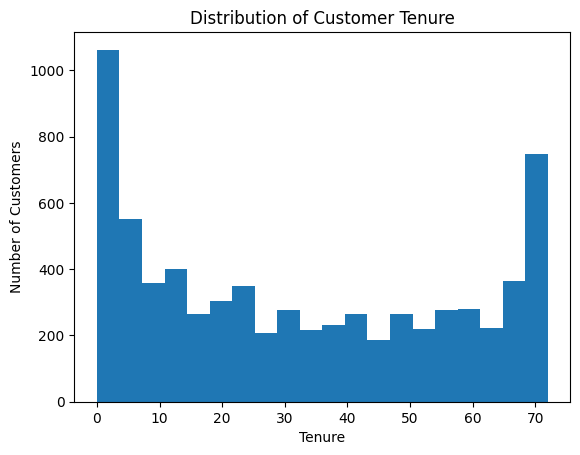

In [11]:
# Task 12 — numerical feature 1: distribution plot
df["tenure"].plot(kind="hist", bins=20)
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

**Observation:** Most customers have lower to medium tenure, while fewer customers have been with the company for a very long time. This shows that the dataset contains many newer customers.

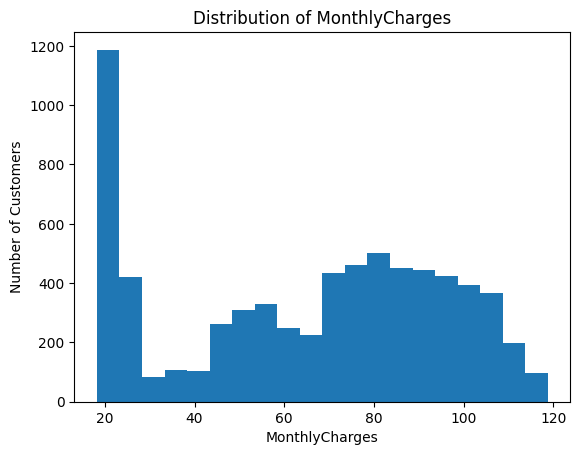

In [12]:
# Task 12 — numerical feature 2: distribution plot
df["MonthlyCharges"].plot(kind="hist", bins=20)
plt.xlabel("MonthlyCharges")
plt.ylabel("Number of Customers")
plt.title("Distribution of MonthlyCharges")
plt.show()

**Observation:** Monthly charges are spread across a wide range of values. There are more customers around the middle range, while fewer customers have very high monthly charges.

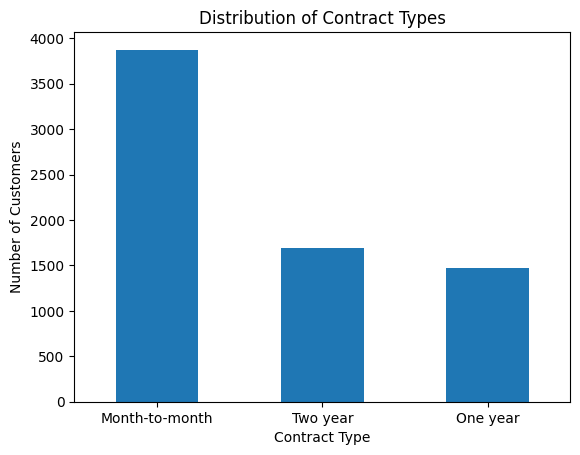

In [13]:
# Task 12 — categorical feature 1: distribution plot
df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Types")
plt.xticks(rotation=0)
plt.show()

**Observation:** Most customers have a month-to-month contract. One-year and two-year contracts have fewer customers compared to month-to-month contracts.

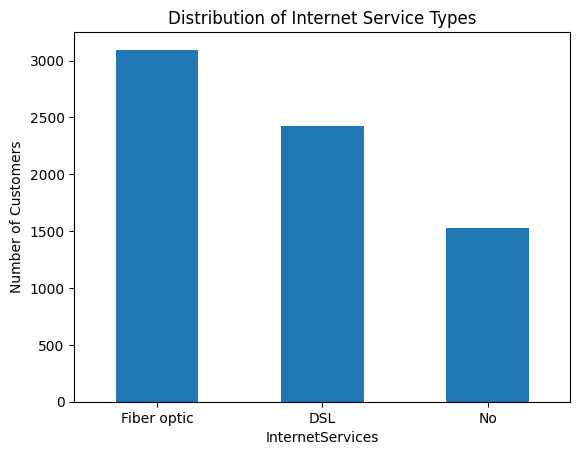

In [14]:
# Task 12 — categorical feature 2: distribution plot
df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("InternetServices")
plt.ylabel("Number of Customers")
plt.title("Distribution of Internet Service Types")
plt.xticks(rotation=0)
plt.show()

**Observation:** DSL and Fiber optic are the main internet service types in the dataset, while some customers do not have internet service. Fiber optic has a large number of customers.

**Answer 13 (outliers / skew and possible explanation):**
tenure does not show many extreme outliers because it has a fixed range of months. MonthlyCharges has a wider spread 
and may contain some higher values..

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [16]:
# Task 14 — churn counts and percentages
print('Number of churn:')
print(df['Churn'].value_counts())
print('Percentage of churn:')
print(df['Churn'].value_counts(normalize=True)*100)

Number of churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Percentage of churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
There are 5,174 customers who did not churn, which is about 73.46% of the dataset. There are 1,869 customers who churned, which is about 26.54%. 
Therefore, the target variable is imbalanced because the number of customers who stayed is much higher than the number who churned.

**Answer 15 (why imbalance might matter later):**
Class imbalance can affect the performance of a classification model because the model may learn more from the larger class. 
In this case, it may predict more customers as "No Churn" and still appear to have good accuracy, even if it does 
not identify enough customers who actually churn.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [17]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
print(contract_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


**Observation:** Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.
**Evidence:** The churn percentage is highest for month-to-month customers, while two-year contract customers have the lowest churn rate.
**Possible Explanation:** Month-to-month customers have less commitment, so they may find it easier to leave the company.

In [19]:
# Task 16 — categorical feature 2 vs Churn
intService_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
print(intService_churn)

Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


**Observation:** Customers using Fiber optic internet have a higher churn rate compared with customers using DSL or having no internet service.
**Evidence:** The churn percentage is highest for Fiber optic customers, while customers with no internet services have the lowest churn rate
**Possible Explanation:** The higher churn could be related to service experience, prices, or other factors associated with Fiber optic customers.

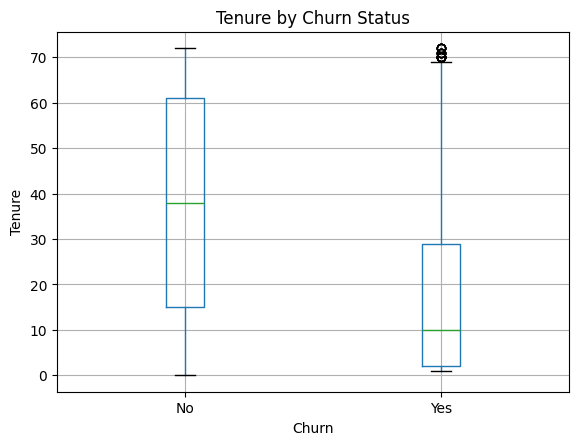

In [20]:
# Task 17 — numerical feature 1 vs Churn
df.boxplot(column="tenure", by="Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.show()

**Observation:** Customers who churn tend to have lower tenure than customers who stay.
**Evidence:** The churned group has a lower median tenure compared with the non-churned group.
**Possible Explanation:** Newer customers may not have developed a strong connection with the company yet, so they may be more likely to leave.

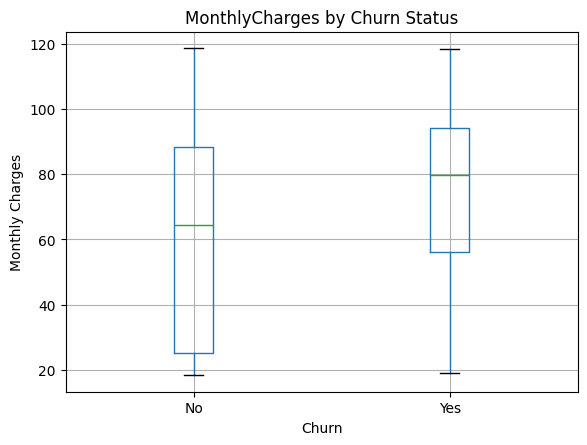

In [22]:
# Task 17 — numerical feature 2 vs Churn
df.boxplot(column="MonthlyCharges", by="Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("MonthlyCharges by Churn Status")
plt.suptitle("")
plt.show()

**Observation:** Customers who churn generally have higher monthly charges than customers who stay.
**Evidence:** The median monthly charge for the churned group is higher than for the non-churned group.
**Possible Explanation:** Customers paying higher monthly charges may be more sensitive to the cost of the service.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102411
tenure               0.016567  1.000000        0.247900      0.825880
MonthlyCharges       0.220173  0.247900        1.000000      0.651065
TotalCharges         0.102411  0.825880        0.651065      1.000000


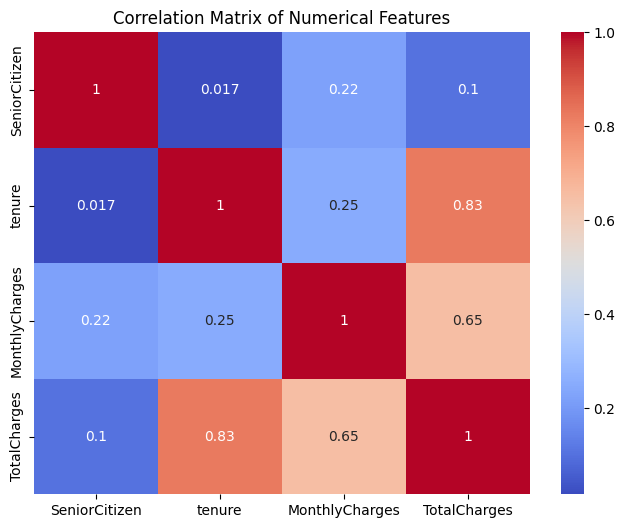

In [3]:
# Task 18 — correlation matrix and heatmap
corr_matrix = clean_df.corr(numeric_only=True)
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Answer 18 (most correlated pairs):**
The strongest correlation is between tenure and TotalCharges (about 0.83), which makes sense since customers who stay longer naturally build up more total charges. MonthlyCharges and TotalCharges are also fairly correlated (about 0.65), since a higher monthly rate adds up faster. tenure and MonthlyCharges have a weaker relationship (about 0.25), and SeniorCitizen barely correlates with anything else.

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not mean that one variable causes the other. For example, tenure and TotalCharges are strongly related, 
but longer tenure does not directly cause a customer to have higher monthly charges; customers 
who stay longer simply have more time to accumulate total charges.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
customerID is a possible issue because it is only an identifier and does not provide meaningful information about 
whether a customer will churn. It should not be used as an input feature for the ML model.

**Answer 21 (what would go wrong):**
If customerID is included in the model, it may add useless information and make the model more complicated 
without helping it understand customer behavior. If Churn were included as an input, it would cause 
data leakage because the model would already be given the answer it is supposed to predict.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | It only identifies a customer, nothing to do with prediction |
| tenure | Numerical | Feature | Keep | It tells how long a customer has stayed with the company |
| Contract | Categorical | Feature | Keep | It can be related to the churn |
| Churn | Categorical | Target | Keep | It is the value that has to be predicted |
| gender | Categorical | Feature | Keep | It is a customer feature |
| SeniorCitizen | Numerical | Feature | Keep | It represents whether the customer is a senior citizen |
| Partner | Categorical | Feature | Keep | It describes the customer's personal situation |
| Dependents | Categorical | Feature | Keep | It may be related to customer behavior and churn |
| PhoneService | Categorical | Feature | Keep | It describes the service used by the customer |
| MultipleLines | Categorical | Feature | Keep | It gives information about the customer's phone service |
| InternetService | Categorical | Feature | Keep | Different internet services may have different churn rates |
| OnlineSecurity | Categorical | Feature | Keep | It describes an additional service used by the customer |
| OnlineBackup | Categorical | Feature | Keep | It describes an additional service used by the customer |
| DeviceProtection | Categorical | Feature | Keep | It describes an additional service used by the customer |
| TechSupport | Categorical | Feature | Keep | It may be related to customer satisfaction and churn |
| StreamingTV | Categorical | Feature | Keep | It describes the services subscribed to by the customer |
| StreamingMovies | Categorical | Feature | Keep | It describes the services subscribed to by the customer |
| PaperlessBiling | Categorical | Feature | Keep | It describes the customer's billing preference |
| PaymentMethod | Categorical | Feature | Keep | Payment method may be related to customer behavior |
| MonthlyCharges | Numerical | Feature | Keep | It represents the customer's monthly charge |
| TotalCharges | Numerical | Feature | Keep | It represents the total amount charged, but its data type needs correction and blank values need handling |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [10]:
# Task 23 — assemble clean_df from your cleaning decisions
#clean_df = df.copy() # already done in part 4

clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'],errors='coerce')
clean_df['TotalCharges']= clean_df['TotalCharges'].fillna(0)
clean_df = clean_df.drop(columns=['customerID'])
print('Duplicates before removal:',clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()
clean_df.info()
# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


Duplicates before removal: 22
<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-n

In [11]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print('Dataset info: ')
clean_df.info()
print('Missing values: ')
print(clean_df.isnull().sum())
print('Duplicates: ')
print(clean_df.duplicated().sum())

Dataset info: 
<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Most of the customers in the dataset did not churn.
- Evidence: 5,174 customers (73.46%) did not churn, while 1,869 customers (26.54%) churned.
- Interpretation: Churn is less common than staying, so the target variable is imbalanced.

**Finding 2**
- Observation: Contract type has a claer relationship with churn.
- Evidence: Month-to-month customers had a much higher churn rate than churn rate than customers with one or two years contracts.
- Interpretation: Customers with longer contract are less likely to churn.

**Finding 3**
- Observation: Customers who churn tend to have lower tenure.
- Evidence: The boxplot showed that the churned group generally had lower tenure than the customers who stayed.
- Interpretation: Newer customers may be more likely to leave because they have had less time to build a relationship with the company.

**Finding 4**
- Observation: Customers who churn generally have higher monthly charges.
- Evidence: The MonthlyCharges boxplot showed a higher median for the churned group compared with the non-churned group.
- Interpretation: Higher monthly charges may be associated with a greater chance of churn, although this does not mean that higher charges directly cause churn.

**Finding 5**
- Observation: Internet service type is related to churn.
- Evidence: Fiber optic customers had a higher churn rate than DSL customers and customers with no internet service.
- Interpretation: This difference may be related to pricing, service experience, or other factors, but the analysis does not prove that the internet service itself causes churn.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   **Answer:** The important issue was TotalCharges column. It was stored as object instead of numerical type and had blank values. So it was needed to convert its type and handle the missing values.
    
2. What was the most interesting pattern you discovered?
   **Answer:** The most interesting pattern was that month-to-month customers had a much higher churn rate than customers with one-year or two-year contracts.
       
3. Which feature seems most useful for predicting churn?
   **Answer:** Contract seems to be one of the most useful features because there was a clear difference in churn rates between the different contract types.
       
4. Which feature should probably not be used, and why?
   **Answer:** CustomerID. As it was just an identifier and was not helpful in finding customers who churn.
       
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   **Answer:** The categorical features will need to be converted into a form that an ML model can use. The numerical features should also be checked for their data types and unusual values, and the target variable Churn will need to be separated from the input features.
       
6. What would you do next if you had another 3 hours?
   **Answer:** I would explore more features against churn and look more closely at the customers who churned. I would also prepare the dataset for the ML model and compare which features are most useful for predicting churn.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook